# Análise dos resultados da metaheurística Simulated Annealing (SA) — α = 0.8

Resultados em `stochastic-results-sa/` no padrão:
`experiment-{alpha}-{temperature}-{temperature_max}-{alpha_sa}-{max_iters_sa}-{delta_type}-{first_improve}-{use_preprocessing}`

**Objetivo:** Identificar qual combinação de parâmetros SA apresentou o melhor resultado final, considerando apenas α = 0.8.

Parâmetros SA avaliados:
- `temperature`: temperatura inicial
- `temperature_max`: número máximo de reaquecimentos
- `alpha_sa`: fator de resfriamento
- `max_iters_sa`: iterações por temperatura
- `delta_type`: tipo de perturbação (moderate / weak)
- `first_improve`: aceitação do primeiro melhoramento (0 / 1)
- `use_preprocessing`: uso de pré-processamento (0 / 1)

In [4]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.figsize"] = (10, 6)
matplotlib.rcParams["axes.grid"] = True
matplotlib.rcParams["grid.alpha"] = 0.3

import analysis_utils
import importlib
importlib.reload(analysis_utils)

from analysis_utils import (
    parse_sa_result,
    parse_experiment_folder_sa,
    parse_experiment_name_sa,
    export_sa_best_to_latex,
    export_sa_four_delta_prep_to_latex,
    export_sa_prep_binary_to_latex,
    export_sa_top_config_ranking_to_latex,
    instance_sort_key,
    load_all_instance_data,
    parse_graph_file,
)

BASE_SA = Path("/home/carlos/Documentos/stoch-results/stochastic-results-sa")
INSTANCE_FOLDERS = ["instances/simulated-alto-santo", "instances/simulated-limoeiro"]
ALPHA = 0.8

if not BASE_SA.exists():
    raise FileNotFoundError(f"Pasta {BASE_SA} não encontrada.")

In [5]:
raw = parse_experiment_folder_sa(BASE_SA)
records = [r for _, r in raw]
df_raw = pd.DataFrame(records)

params = [parse_experiment_name_sa(r["experiment"]) for _, r in raw]
for key in (params[0].keys() if params else []):
    df_raw[key] = [p.get(key) for p in params]

df_all = df_raw[df_raw["alpha"] == ALPHA].copy().reset_index(drop=True)

df_all["sa_config"] = (
    "temp-" + df_all["temperature"].astype(str)
    + "-tmax-" + df_all["temperature_max"].astype(str)
    + "-asa-" + df_all["alpha_sa"].astype(str)
    + "-mi-" + df_all["max_iters_sa"].astype(str)
    + "-d-" + df_all["delta_type"]
    + "-fi-" + df_all["first_improve"].astype(str)
    + "-p-" + df_all["use_preprocessing"].astype(str)
)

df_all["city"] = df_all["instance_name"].apply(lambda x: "-".join(x.split("-")[:-2]))
df_all["map_size"] = df_all["instance_name"].apply(
    lambda x: int(x.split("-")[-2]) if x.split("-")[-2].isdigit() else 0
)

print(f"Total bruto: {len(df_raw)}")
print(f"Total com alpha={ALPHA}: {len(df_all)}")
print(f"Configurações SA distintas: {df_all['sa_config'].nunique()}")
print(f"Instâncias: {df_all['instance_name'].nunique()}")

Total bruto: 12745
Total com alpha=0.8: 12707
Configurações SA distintas: 367
Instâncias: 36


## 1. Melhoria obtida pelo SA (Start_LB → LB)

In [6]:
df_all["improvement"] = df_all["LB"] - df_all["Start_LB"]
df_all["improvement_pct"] = np.where(
    df_all["Start_LB"] > 0,
    100 * df_all["improvement"] / df_all["Start_LB"],
    np.nan,
)

agg = df_all.groupby("sa_config").agg(
    LB_medio=("LB", "mean"),
    improvement_medio=("improvement", "mean"),
    runtime_medio=("Runtime", "mean"),
    attended_s0_medio=("attended_s0", "mean"),
    n_instances=("instance_name", "nunique"),
).reset_index()

n_inst_total = df_all["instance_name"].nunique()
n_before = len(agg)
agg = agg[agg["n_instances"] == n_inst_total].copy()
print(
    f"Filtro de cobertura: mantidas {len(agg)}/{n_before} configs com {n_inst_total}/{n_inst_total} instâncias."
)
agg = agg.sort_values("LB_medio", ascending=False)

_cfg = df_all.groupby("sa_config", as_index=False).first()[
    [
        "sa_config",
        "temperature",
        "temperature_max",
        "alpha_sa",
        "max_iters_sa",
        "delta_type",
        "first_improve",
        "use_preprocessing",
    ]
]
agg = agg.merge(_cfg, on="sa_config", how="left")


def _sa_configuration_paper(row) -> str:
    d = str(row["delta_type"]).strip().lower()
    disturb = (
        "Moderate (second-stage adjustments)"
        if d == "moderate"
        else "Weak (first-stage only)"
    )
    fi = "on" if int(row["first_improve"]) == 1 else "off"
    prep = "on" if int(row["use_preprocessing"]) == 1 else "off"
    return (
        f"T_init={row['temperature']}, T_max={row['temperature_max']}, "
        f"alpha_SA={row['alpha_sa']}, max inner iter.={row['max_iters_sa']}, "
        f"{disturb}, first impr. {fi}, prep. {prep}"
    )


agg["configuration"] = agg.apply(_sa_configuration_paper, axis=1)

agg_display_cols = {
    "configuration": "Configuration",
    "LB_medio": "Mean LB",
    "improvement_medio": "Mean improvement",
    "runtime_medio": "Mean runtime (s)",
    "attended_s0_medio": "Mean attended blocks (s0)",
}
agg_display = agg[list(agg_display_cols.keys())].rename(columns=agg_display_cols)

print(f"Configurações SA avaliadas: {len(agg)}")
print(f"\nResumo geral:")
print(f"  LB médio — min: {agg['LB_medio'].min():.2f}, max: {agg['LB_medio'].max():.2f}")
print(f"  Melhoria média — min: {agg['improvement_medio'].min():.4f}, max: {agg['improvement_medio'].max():.4f}")

top15 = agg.head(5).reset_index(drop=True)
top15.insert(0, "rank", range(1, len(top15) + 1))
latex_df = top15[
    [
        "rank",
        "temperature",
        "temperature_max",
        "alpha_sa",
        "max_iters_sa",
        "delta_type",
        "first_improve",
        "use_preprocessing",
        "LB_medio",
        "improvement_medio",
        "runtime_medio",
        "attended_s0_medio",
    ]
]
OUT_SA_RANK = Path("latex-tables-sa")
OUT_SA_RANK.mkdir(parents=True, exist_ok=True)
cap_rank = (
    f"Top 15 SA parameter combinations by mean LB (alpha={ALPHA}). "
    "Moderate: disturbance evaluation with second-stage adjustments; "
    "Weak: first-stage evaluation only."
)
tex_rank = export_sa_top_config_ranking_to_latex(
    latex_df, caption=cap_rank, label="tab:sa-top-config-ranking"
)
path_rank = OUT_SA_RANK / "table-sa-top-config-ranking.tex"
path_rank.write_text(tex_rank, encoding="utf-8")
print(f"LaTeX (top 15 configs): {path_rank.resolve()}")

# --- 10 piores configurações (por LB médio crescente, já filtradas por cobertura completa) ---
bottom10 = (
    agg.sort_values("LB_medio", ascending=True).head(5).reset_index(drop=True)
)
bottom10.insert(0, "rank", range(1, len(bottom10) + 1))

worst_latex_df = bottom10[
    [
        "rank",
        "temperature",
        "temperature_max",
        "alpha_sa",
        "max_iters_sa",
        "delta_type",
        "first_improve",
        "use_preprocessing",
        "LB_medio",
        "improvement_medio",
        "runtime_medio",
        "attended_s0_medio",
    ]
]
cap_worst = (
    f"10 worst SA parameter combinations by mean LB (alpha={ALPHA}). "
    "Moderate: disturbance evaluation with second-stage adjustments; "
    "Weak: first-stage evaluation only."
)
tex_worst = export_sa_top_config_ranking_to_latex(
    worst_latex_df, caption=cap_worst, label="tab:sa-bottom-config-ranking"
)
path_worst = OUT_SA_RANK / "table-sa-bottom-config-ranking.tex"
path_worst.write_text(tex_worst, encoding="utf-8")
print(f"LaTeX (10 worst configs): {path_worst.resolve()}")

print("\n10 piores configurações (coverage = nº de instâncias atendidas):")
bottom_cols = [
    "rank",
    "configuration",
    "LB_medio",
    "improvement_medio",
    "runtime_medio",
    "attended_s0_medio",
    "n_instances",
]
bottom_display = bottom10[bottom_cols].rename(
    columns={
        "rank": "Rank",
        "configuration": "Configuration",
        "LB_medio": "Mean LB",
        "improvement_medio": "Mean improvement",
        "runtime_medio": "Mean runtime (s)",
        "attended_s0_medio": "Mean attended blocks (s0)",
        "n_instances": f"Coverage (/ {n_inst_total})",
    }
)
display(bottom_display)

agg_display.head(10)

Filtro de cobertura: mantidas 134/367 configs com 36/36 instâncias.
Configurações SA avaliadas: 134

Resumo geral:
  LB médio — min: 147.15, max: 147.62
  Melhoria média — min: 0.4690, max: 1.1442
LaTeX (top 15 configs): /home/carlos/Documentos/cbrp-methodologies/latex-tables-sa/table-sa-top-config-ranking.tex
LaTeX (10 worst configs): /home/carlos/Documentos/cbrp-methodologies/latex-tables-sa/table-sa-bottom-config-ranking.tex

10 piores configurações (coverage = nº de instâncias atendidas):


,Rank,Configuration,Mean LB,Mean improvement,Mean runtime (s),Mean attended blocks (s0),Coverage (/ 36)
0,1,"T_init=1.0, T_max=100, alpha_SA=1.25, max inne...",147.146667,0.469000,214.352372,35.250000,36
1,2,"T_init=1.0, T_max=100, alpha_SA=1.1, max inner...",147.152444,0.474778,464.173772,35.027778,36
2,3,"T_init=1.0, T_max=100, alpha_SA=1.05, max inne...",147.169222,0.491556,247.619072,35.611111,36
3,4,"T_init=1.0, T_max=100, alpha_SA=1.2, max inner...",147.169556,0.491889,262.465533,35.222222,36
4,5,"T_init=1.0, T_max=100, alpha_SA=1.25, max inne...",147.173444,0.495778,118.615930,36.444444,36


,Configuration,Mean LB,Mean improvement,Mean runtime (s),Mean attended blocks (s0)
0,"T_init=1.0, T_max=100, alpha_SA=1.25, max inne...",147.615444,1.144222,68.578645,36.138889
1,"T_init=1.0, T_max=100, alpha_SA=1.1, max inner...",147.604222,1.133000,475.887056,32.638889
2,"T_init=1.0, T_max=100, alpha_SA=1.15, max inne...",147.601333,1.130111,177.273278,35.638889
3,"T_init=1.0, T_max=100, alpha_SA=1.25, max inne...",147.554889,1.083667,69.616379,36.138889
4,"T_init=1.0, T_max=100, alpha_SA=1.05, max inne...",147.539444,1.068222,895.629483,31.916667
5,"T_init=1.0, T_max=100, alpha_SA=1.05, max inne...",147.533333,1.062111,256.456136,33.555556
6,"T_init=1.0, T_max=100, alpha_SA=1.25, max inne...",147.531222,1.060000,227.048450,34.888889
7,"T_init=1.0, T_max=100, alpha_SA=1.2, max inner...",147.520556,1.049333,148.466322,35.833333
8,"T_init=1.0, T_max=100, alpha_SA=1.25, max inne...",147.519667,1.048444,224.970650,32.916667
9,"T_init=1.0, T_max=300, alpha_SA=1.05, max inne...",147.511667,0.834000,299.818808,35.527778


## 2. Ranking das configurações SA (melhor LB médio)

Total de instâncias: 36
Configurações com pelo menos 1 vitória: 21

Rank   Vitórias   % Inst   LB médio (vencidas)  Config
──────────────────────────────────────────────────────────────────────────────────────────
1            15    41.7%              105.3765  temp-1.0-tmax-100-asa-1.05-mi-100-d-moderate-fi-0-p-0
2             2     5.6%              158.1080  temp-1.0-tmax-100-asa-1.2-mi-50-d-moderate-fi-1-p-0
3             1     2.8%              234.2680  temp-1.0-tmax-100-asa-1.05-mi-100-d-moderate-fi-0-p-1
4             1     2.8%              149.4680  temp-1.0-tmax-100-asa-1.05-mi-100-d-weak-fi-0-p-0
5             1     2.8%              159.2720  temp-1.0-tmax-100-asa-1.05-mi-100-d-moderate-fi-1-p-1
6             1     2.8%              221.8800  temp-1.0-tmax-100-asa-1.05-mi-200-d-moderate-fi-1-p-1
7             1     2.8%              127.6960  temp-1.0-tmax-100-asa-1.05-mi-200-d-weak-fi-0-p-1
8             1     2.8%              101.2480  temp-1.0-tmax-100-asa-1.1-mi-100-d

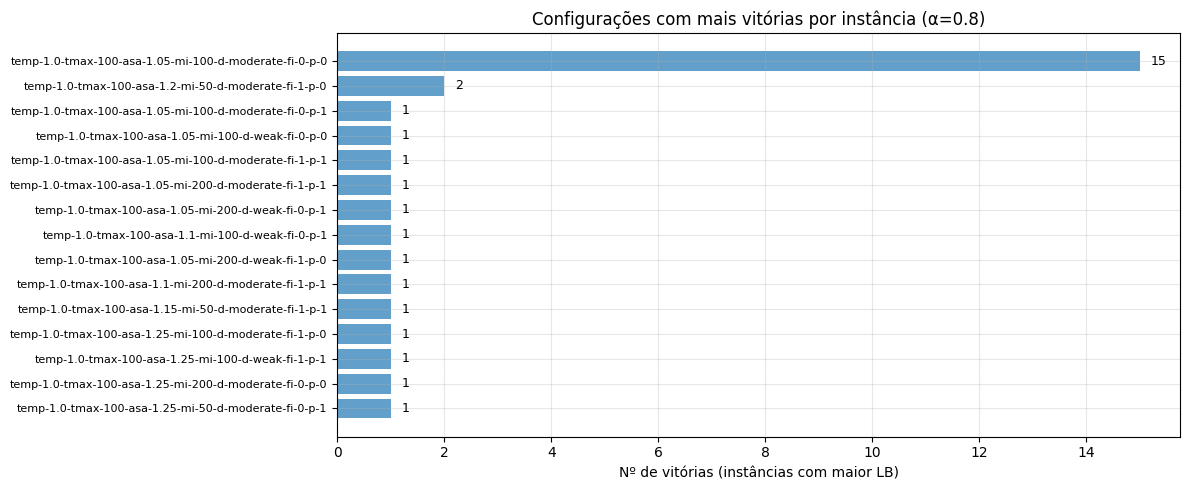

In [7]:
idx_best_per_instance = df_all.groupby("instance_name")["LB"].idxmax()
winners = df_all.loc[idx_best_per_instance, ["instance_name", "sa_config", "LB"]].copy()

wins = (
    winners.groupby("sa_config")
    .agg(vitorias=("instance_name", "count"), LB_medio=("LB", "mean"))
    .sort_values("vitorias", ascending=False)
    .reset_index()
)

total_instances = df_all["instance_name"].nunique()

print(f"Total de instâncias: {total_instances}")
print(f"Configurações com pelo menos 1 vitória: {len(wins)}\n")

print(f"{'Rank':<5} {'Vitórias':>9} {'% Inst':>8}  {'LB médio (vencidas)':>20}  Config")
print("─" * 90)
for i, row in wins.iterrows():
    rank = i + 1
    pct = 100 * row["vitorias"] / total_instances
    print(f"{rank:<5} {int(row['vitorias']):>9} {pct:>7.1f}%  {row['LB_medio']:>20.4f}  {row['sa_config']}")
    if rank >= 20:
        break

best_wins_config = wins.iloc[0]["sa_config"]
best_wins_count = int(wins.iloc[0]["vitorias"])
print(f"\nConfig com mais vitórias: {best_wins_config}")
print(f"Vitórias: {best_wins_count}/{total_instances} ({100*best_wins_count/total_instances:.1f}%)")

fig, ax = plt.subplots(figsize=(12, 5))
top_wins = wins.head(15)
bars = ax.barh(range(len(top_wins)), top_wins["vitorias"].values, color="C0", alpha=0.7)
ax.set_yticks(range(len(top_wins)))
ax.set_yticklabels(top_wins["sa_config"].values, fontsize=8)
ax.set_xlabel("Nº de vitórias (instâncias com maior LB)")
ax.set_title(f"Configurações com mais vitórias por instância (α={ALPHA})")
ax.invert_yaxis()

for bar, v in zip(bars, top_wins["vitorias"].values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(int(v)), va="center", fontsize=9)

plt.tight_layout()
plt.show()

In [8]:
csv_rows = []
for _, row in df_all.loc[idx_best_per_instance].iterrows():
    csv_rows.append({
        "instance_name": row["instance_name"],
        "best_LB": row["LB"],
        "Start_LB": row["Start_LB"],
        "improvement": row["LB"] - row["Start_LB"],
        "attended_s0": row["attended_s0"],
        "Runtime": row["Runtime"],
        "sa_config": row["sa_config"],
        "experiment": row["experiment"],
    })

df_csv = pd.DataFrame(csv_rows).sort_values(
    "instance_name", key=lambda c: c.map(instance_sort_key)
)

csv_path = Path("sa-best-lbs.csv")
df_csv.to_csv(csv_path, index=False)
print(f"CSV salvo em {csv_path} ({len(df_csv)} instâncias)")
df_csv

CSV salvo em sa-best-lbs.csv (36 instâncias)


,instance_name,best_LB,Start_LB,improvement,attended_s0,Runtime,sa_config,experiment
12,alto-santo-500-1,171.920,171.920,0.000,46,60.9711,temp-1.0-tmax-100-asa-1.05-mi-100-d-moderate-f...,experiment-0.8-1.0-100-1.05-100-moderate-0-0
13,alto-santo-500-2,65.600,65.600,0.000,47,59.0870,temp-1.0-tmax-100-asa-1.05-mi-100-d-moderate-f...,experiment-0.8-1.0-100-1.05-100-moderate-0-0
14,alto-santo-500-3,106.180,106.180,0.000,33,65.3440,temp-1.0-tmax-100-asa-1.05-mi-100-d-moderate-f...,experiment-0.8-1.0-100-1.05-100-moderate-0-0
15,alto-santo-500-4,90.580,90.580,0.000,22,67.0840,temp-1.0-tmax-100-asa-1.05-mi-100-d-moderate-f...,experiment-0.8-1.0-100-1.05-100-moderate-0-0
16,alto-santo-500-5,83.720,83.720,0.000,48,69.7658,temp-1.0-tmax-100-asa-1.05-mi-100-d-moderate-f...,experiment-0.8-1.0-100-1.05-100-moderate-0-0
17,alto-santo-500-6,189.820,189.820,0.000,45,59.0393,temp-1.0-tmax-100-asa-1.05-mi-100-d-moderate-f...,experiment-0.8-1.0-100-1.05-100-moderate-0-0
0,alto-santo-1000-1,221.880,220.880,1.000,40,555.6770,temp-1.0-tmax-100-asa-1.05-mi-200-d-moderate-f...,experiment-0.8-1.0-100-1.05-200-moderate-1-1
1,alto-santo-1000-2,89.496,88.492,1.004,18,266.8860,temp-1.0-tmax-100-asa-1.05-mi-100-d-moderate-f...,experiment-0.8-1.0-100-1.05-100-moderate-0-0
2,alto-santo-1000-3,149.468,149.464,0.004,35,277.4730,temp-1.0-tmax-100-asa-1.05-mi-100-d-weak-fi-0-p-0,experiment-0.8-1.0-100-1.05-100-weak-0-0
3,alto-santo-1000-4,127.696,127.692,0.004,34,455.9610,temp-1.0-tmax-100-asa-1.05-mi-200-d-weak-fi-0-p-1,experiment-0.8-1.0-100-1.05-200-weak-0-1


## 4. Impacto de cada parâmetro SA no LB

In [9]:
sa_params = ["temperature", "temperature_max", "alpha_sa",
             "max_iters_sa", "delta_type", "first_improve", "use_preprocessing"]

for param in sa_params:
    if param not in df_all.columns:
        continue
    effect = df_all.groupby(param).agg(
        LB_medio=("LB", "mean"),
        LB_std=("LB", "std"),
        improvement_medio=("improvement", "mean"),
        count=("LB", "count"),
    ).sort_values("LB_medio", ascending=False)
    print(f"\n{'─'*50}")
    print(f"{param} (maior LB = melhor):")
    print(effect.to_string())


──────────────────────────────────────────────────
temperature (maior LB = melhor):
               LB_medio     LB_std  improvement_medio  count
temperature                                                 
1.0          143.457710  80.558803           0.898215  10730
5.0          140.142824  78.269569           0.987061   1977

──────────────────────────────────────────────────
temperature_max (maior LB = melhor):
                   LB_medio     LB_std  improvement_medio  count
temperature_max                                                 
100              145.087507  81.510694           0.842225   6297
300              141.727688  79.457094           0.956524   2330
500              140.327667  78.534827           0.998020   2040
1000             140.320394  78.550058           0.990747   2040

──────────────────────────────────────────────────
alpha_sa (maior LB = melhor):
            LB_medio     LB_std  improvement_medio  count
alpha_sa                                            

## 5. Resultados detalhados da melhor configuração

## 8. Comparação SA: moderate/weak × pré-processamento e melhor solução com vs sem prep.

Por instância: maior **LB**; em empate, menor **Runtime**. Exportação LaTeX em `latex-tables-sa/`.

Configuração fixa: `temp=1.0, tmax=100, α_sa=1.05, iters=100, delta=moderate, first_improve=0`.

In [10]:
# 4 configs fixas (1ª do top15 por (delta_type, use_preprocessing)) + tabelas LaTeX + CSV p/ R.
import importlib
import analysis_utils
importlib.reload(analysis_utils)
from analysis_utils import export_sa_four_delta_prep_to_latex, export_sa_prep_binary_to_latex

def _best_sa_row_per_instance(df_sub):
    if len(df_sub) == 0:
        return pd.DataFrame(columns=["instance_name", "Start_LB", "LB", "Runtime"])
    return (
        df_sub.sort_values(
            ["instance_name", "LB", "Runtime"],
            ascending=[True, False, True],
        )
        .drop_duplicates("instance_name", keep="first")[
            ["instance_name", "Start_LB", "LB", "Runtime"]
        ]
    )


df_meta = (
    df_all.sort_values("instance_name")
    .drop_duplicates("instance_name", keep="first")[["instance_name", "N", "M", "B", "Alpha"]]
)

# --- 1) Selecionar a 1ª configuração do top15 para cada (delta_type, use_preprocessing) ---
_pool = top15 if "top15" in globals() else agg

def _pick_cfg(delta_type: str, prep: int) -> str:
    src = _pool[(_pool["delta_type"] == delta_type) & (_pool["use_preprocessing"] == prep)]
    if len(src) == 0:
        src = agg[(agg["delta_type"] == delta_type) & (agg["use_preprocessing"] == prep)]
    if len(src) == 0:
        raise ValueError(f"Sem config para delta_type={delta_type}, prep={prep}.")
    return src.sort_values("LB_medio", ascending=False).iloc[0]["sa_config"]

# Configuração weak+prep fixada manualmente — pedido do usuário; o LB dessa
# coluna será sobrescrito mais abaixo com o melhor LB global por instância.
FIXED_CFG_W1 = "temp-1.0-tmax-100-asa-1.25-mi-50-d-weak-fi-1-p-1"

CFG_W0 = _pick_cfg("weak", 0)
CFG_M0 = _pick_cfg("moderate", 0)
CFG_W1 = FIXED_CFG_W1
CFG_M1 = _pick_cfg("moderate", 1)
print("Configs escolhidas (top-1 do top15 por delta×prep, exceto weak+prep que é fixa):")
print(f"  weak   / noprep: {CFG_W0}")
print(f"  mod.   / noprep: {CFG_M0}")
print(f"  weak   / prep:   {CFG_W1}  [fixada — LB será o melhor global por instância]")
print(f"  mod.   / prep:   {CFG_M1}")

if CFG_W1 not in df_all["sa_config"].unique():
    raise ValueError(f"Configuração {CFG_W1!r} não encontrada em df_all['sa_config'].")


def _rows_for_config(cfg: str) -> pd.DataFrame:
    sub = df_all[df_all["sa_config"] == cfg][[
        "instance_name", "Start_LB", "LB", "Runtime"
    ]].copy()
    sub = sub.drop_duplicates("instance_name", keep="first")
    return sub


m0 = _rows_for_config(CFG_M0).rename(columns={"LB": "LB_m0", "Runtime": "RT_m0", "Start_LB": "SL_m0"})
w0 = _rows_for_config(CFG_W0).rename(columns={"LB": "LB_w0", "Runtime": "RT_w0", "Start_LB": "SL_w0"})
m1 = _rows_for_config(CFG_M1).rename(columns={"LB": "LB_m1", "Runtime": "RT_m1", "Start_LB": "SL_m1"})
w1 = _rows_for_config(CFG_W1).rename(columns={"LB": "LB_w1", "Runtime": "RT_w1", "Start_LB": "SL_w1"})

df_four = (
    df_meta.merge(m0, on="instance_name", how="left")
    .merge(w0, on="instance_name", how="left")
    .merge(m1, on="instance_name", how="left")
    .merge(w1, on="instance_name", how="left")
)
df_four = df_four.sort_values("instance_name", key=lambda c: c.map(instance_sort_key))

# --- Override: para a config weak+prep fixada (CFG_W1), substitui o LB
# pelo melhor LB obtido por qualquer experimento na mesma instância.
# RT_w1 e SL_w1 permanecem como o run real dessa configuração.
_best_lb = (
    df_all.groupby("instance_name", as_index=False)["LB"].max()
    .rename(columns={"LB": "LB_w1_best"})
)
df_four = df_four.merge(_best_lb, on="instance_name", how="left")
df_four["LB_w1"] = df_four["LB_w1_best"]
df_four = df_four.drop(columns=["LB_w1_best"])
print(
    f"\n[override] LB_w1 substituído pelo melhor LB global por instância "
    f"({df_four['LB_w1'].notna().sum()}/{len(df_four)} instâncias com valor)."
)

fmt_four = {c: "{:.2f}" for c in df_four.columns if c not in ("instance_name", "Alpha")}
fmt_four["Alpha"] = "{:.1f}"
print("\nTabela 1 — 4 configs fixas (moderate/weak × prep), LB / Tempo / Start_LB por instância")
display(df_four.style.format(fmt_four, na_rep="-").hide(axis="index"))

# --- 2) Tabela binária (sem vs com prep): melhor corrida global por instância ---
p0 = _best_sa_row_per_instance(df_all[df_all["use_preprocessing"] == 0]).rename(
    columns={"LB": "LB_sp", "Runtime": "RT_sp", "Start_LB": "SL_sp"}
)
p1 = _best_sa_row_per_instance(df_all[df_all["use_preprocessing"] == 1]).rename(
    columns={"LB": "LB_cp", "Runtime": "RT_cp", "Start_LB": "SL_cp"}
)
df_prep2 = df_meta.merge(p0, on="instance_name").merge(p1, on="instance_name")
df_prep2 = df_prep2.sort_values("instance_name", key=lambda c: c.map(instance_sort_key))
df_prep2["ΔLB"] = df_prep2["LB_cp"] - df_prep2["LB_sp"]
df_prep2["ΔRuntime"] = df_prep2["RT_cp"] - df_prep2["RT_sp"]

cols_prep = [
    "instance_name", "N", "M", "B", "Alpha",
    "LB_sp", "RT_sp", "SL_sp", "LB_cp", "RT_cp", "SL_cp", "ΔLB", "ΔRuntime",
]
fmt_prep = {c: "{:.2f}" for c in cols_prep if c not in ("instance_name", "Alpha", "ΔLB", "ΔRuntime")}
fmt_prep["Alpha"] = "{:.1f}"
fmt_prep["ΔLB"] = "{:+.2f}"
fmt_prep["ΔRuntime"] = "{:+.2f}"
print("\nTabela 2 — melhor solução sem vs com pré-processamento (qualquer perturbação)")
display(df_prep2[cols_prep].style.format(fmt_prep).hide(axis="index"))

n_lb_better = (df_prep2["ΔLB"] > 0).sum()
n_rt_better = (df_prep2["ΔRuntime"] < 0).sum()
print(f"\nCom prep tem LB maior:    {n_lb_better}/{len(df_prep2)}")
print(f"Com prep é mais rápido:   {n_rt_better}/{len(df_prep2)}")
print(f"ΔLB médio:   {df_prep2['ΔLB'].mean():+.4f}")
print(f"ΔRuntime médio: {df_prep2['ΔRuntime'].mean():+.2f}s")

# --- 3) Exportações LaTeX ---
OUT_SA_CMP = Path("latex-tables-sa")
OUT_SA_CMP.mkdir(parents=True, exist_ok=True)
cap_four = (
    f"Simulated Annealing ($\\alpha$={ALPHA}): 1ª configuração do top-15 por "
    "(perturbação, pré-processamento) — LB, tempo e Start\\_LB por instância."
)
tex_four = export_sa_four_delta_prep_to_latex(
    df_four, caption=cap_four, label="tab:sa-delta-prep-four", use_rowcolor=False
)
path_four = OUT_SA_CMP / "table-sa-delta-prep-four.tex"
path_four.write_text(tex_four, encoding="utf-8")
cap_bin = (
    f"Simulated Annealing ($\\alpha$={ALPHA}): melhor LB por instância sem vs com pré-processamento."
)
tex_bin = export_sa_prep_binary_to_latex(
    df_prep2[
        ["instance_name", "N", "M", "B", "Alpha", "LB_sp", "RT_sp", "SL_sp", "LB_cp", "RT_cp", "SL_cp"]
    ],
    caption=cap_bin,
    label="tab:sa-prep-best-vs-best",
    use_rowcolor=True,
)
path_bin = OUT_SA_CMP / "table-sa-prep-best-vs-best.tex"
path_bin.write_text(tex_bin, encoding="utf-8")

# --- 4) CSV p/ analysis_r.ipynb (scmamp) — LB (quanto maior, melhor) ---
# Formato: 1ª coluna = Instance; demais colunas = métodos.
df_csv = df_four[["instance_name", "LB_w0", "LB_m0", "LB_w1", "LB_m1"]].rename(
    columns={
        "instance_name": "Instance",
        "LB_w0": "SA-Weak",
        "LB_m0": "SA-Moderate",
        "LB_w1": "SA-Weak-Prep",
        "LB_m1": "SA-Moderate-Prep",
    }
)
path_csv = OUT_SA_CMP / "sa-top4-lb.csv"
df_csv.to_csv(path_csv, index=False)

print(f"\nLaTeX (4 cenários):        {path_four.resolve()}")
print(f"LaTeX (sem vs com prep):   {path_bin.resolve()}")
print(f"CSV p/ análise estatística: {path_csv.resolve()}")

Configs escolhidas (top-1 do top15 por delta×prep, exceto weak+prep que é fixa):
  weak   / noprep: temp-1.0-tmax-100-asa-1.25-mi-100-d-weak-fi-0-p-0
  mod.   / noprep: temp-1.0-tmax-300-asa-1.05-mi-50-d-moderate-fi-0-p-0
  weak   / prep:   temp-1.0-tmax-100-asa-1.25-mi-50-d-weak-fi-1-p-1  [fixada — LB será o melhor global por instância]
  mod.   / prep:   temp-1.0-tmax-100-asa-1.25-mi-200-d-moderate-fi-0-p-1

[override] LB_w1 substituído pelo melhor LB global por instância (36/36 instâncias com valor).

Tabela 1 — 4 configs fixas (moderate/weak × prep), LB / Tempo / Start_LB por instância


instance_name,N,M,B,Alpha,SL_m0,LB_m0,RT_m0,SL_w0,LB_w0,RT_w0,SL_m1,LB_m1,RT_m1,SL_w1,LB_w1,RT_w1
alto-santo-500-1,94.00,290.00,52.00,0.8,171.92,171.92,37.62,171.92,171.92,13.63,171.92,171.92,29.56,171.92,171.92,6.23
alto-santo-500-2,94.00,290.00,51.00,0.8,65.60,65.60,44.35,65.60,65.60,17.95,65.60,65.60,32.49,65.60,65.60,9.19
alto-santo-500-3,94.00,290.00,52.00,0.8,106.18,106.18,36.84,106.18,106.18,13.80,106.18,106.18,26.99,106.18,106.18,5.69
alto-santo-500-4,94.00,290.00,52.00,0.8,90.58,90.58,43.67,90.58,90.58,14.05,90.58,90.58,30.71,90.58,90.58,8.32
alto-santo-500-5,94.00,290.00,51.00,0.8,83.72,83.72,41.62,83.72,83.72,15.57,83.72,83.72,30.64,83.72,83.72,7.85
alto-santo-500-6,94.00,290.00,52.00,0.8,189.82,189.82,34.88,189.82,189.82,11.92,189.82,189.82,25.39,189.82,189.82,6.39
alto-santo-1000-1,149.00,464.00,84.00,0.8,219.88,220.88,170.82,219.88,219.88,60.36,220.88,220.88,119.84,220.88,221.88,29.33
alto-santo-1000-2,149.00,464.00,83.00,0.8,88.49,89.50,174.83,88.49,89.50,71.17,88.49,89.50,117.68,88.49,89.50,43.16
alto-santo-1000-3,149.00,464.00,84.00,0.8,149.46,149.47,173.08,149.46,149.47,63.24,149.46,149.46,111.79,149.46,149.47,40.12
alto-santo-1000-4,149.00,464.00,82.00,0.8,127.69,127.69,148.74,127.69,127.69,51.88,127.69,127.69,94.85,127.69,127.70,29.90



Tabela 2 — melhor solução sem vs com pré-processamento (qualquer perturbação)


instance_name,N,M,B,Alpha,LB_sp,RT_sp,SL_sp,LB_cp,RT_cp,SL_cp,ΔLB,ΔRuntime
alto-santo-500-1,94.00,290.00,52.00,0.8,171.92,6.09,171.92,171.92,3.28,171.92,+0.00,-2.81
alto-santo-500-2,94.00,290.00,51.00,0.8,65.60,8.05,65.60,65.60,2.59,65.60,+0.00,-5.46
alto-santo-500-3,94.00,290.00,52.00,0.8,106.18,4.19,106.18,106.18,1.71,106.18,+0.00,-2.48
alto-santo-500-4,94.00,290.00,52.00,0.8,90.58,6.97,90.58,90.58,3.62,90.58,+0.00,-3.36
alto-santo-500-5,94.00,290.00,51.00,0.8,83.72,7.24,83.72,83.72,2.33,83.72,+0.00,-4.91
alto-santo-500-6,94.00,290.00,52.00,0.8,189.82,5.50,189.82,189.82,2.85,189.82,+0.00,-2.65
alto-santo-1000-1,149.00,464.00,84.00,0.8,220.88,71.97,219.88,221.88,19.88,220.88,+1.00,-52.09
alto-santo-1000-2,149.00,464.00,83.00,0.8,89.50,38.19,88.49,89.50,26.03,88.49,+0.00,-12.15
alto-santo-1000-3,149.00,464.00,84.00,0.8,149.47,33.29,149.46,149.47,21.52,149.46,+0.00,-11.77
alto-santo-1000-4,149.00,464.00,82.00,0.8,127.70,28.53,127.69,127.70,21.58,127.69,+0.00,-6.95



Com prep tem LB maior:    14/36
Com prep é mais rápido:   24/36
ΔLB médio:   +0.3687
ΔRuntime médio: +54.60s

LaTeX (4 cenários):        /home/carlos/Documentos/cbrp-methodologies/latex-tables-sa/table-sa-delta-prep-four.tex
LaTeX (sem vs com prep):   /home/carlos/Documentos/cbrp-methodologies/latex-tables-sa/table-sa-prep-best-vs-best.tex
CSV p/ análise estatística: /home/carlos/Documentos/cbrp-methodologies/latex-tables-sa/sa-top4-lb.csv


## 9. Análise estatística: melhor LB médio vs pior LB médio (cobertura completa = 36 instâncias)

Como entre as 4 melhores configs não houve diferença significativa no teste do R, aqui verificamos se **há diferença** entre a melhor e a pior configuração que **resolveu as 36 instâncias**.


In [11]:
# Melhor vs pior config (com cobertura das 36 instâncias): Wilcoxon pareado + CSV p/ R.
import importlib
import analysis_utils
importlib.reload(analysis_utils)
from scipy.stats import wilcoxon

n_total_instances = df_all["instance_name"].nunique()
coverage = (
    df_all.groupby("sa_config")["instance_name"].nunique().rename("n_instances")
)
cov_full = coverage[coverage == n_total_instances].index
print(f"Instâncias no df_all: {n_total_instances}")
print(f"Configs com cobertura completa: {len(cov_full)}/{coverage.size}")

agg_full = agg[agg["sa_config"].isin(cov_full)].copy()
cfg_best = agg_full.sort_values("LB_medio", ascending=False).iloc[0]
cfg_worst = agg_full.sort_values("LB_medio", ascending=True).iloc[0]

print("\nMelhor LB médio (entre configs com 36 instâncias):")
print(f"  sa_config: {cfg_best['sa_config']}")
print(f"  LB médio:  {cfg_best['LB_medio']:.4f}")
print(f"  Runtime médio: {cfg_best['runtime_medio']:.2f}s")
print("\nPior LB médio (entre configs com 36 instâncias):")
print(f"  sa_config: {cfg_worst['sa_config']}")
print(f"  LB médio:  {cfg_worst['LB_medio']:.4f}")
print(f"  Runtime médio: {cfg_worst['runtime_medio']:.2f}s")


def _lb_series_per_instance(cfg: str) -> pd.Series:
    sub = (
        df_all[df_all["sa_config"] == cfg]
        .drop_duplicates("instance_name", keep="first")
        .set_index("instance_name")["LB"]
    )
    return sub


lb_best = _lb_series_per_instance(cfg_best["sa_config"])
lb_worst = _lb_series_per_instance(cfg_worst["sa_config"])

df_cmp_bw = pd.DataFrame(
    {
        "Instance": lb_best.index,
        "LB_best": lb_best.values,
    }
).merge(
    pd.DataFrame(
        {"Instance": lb_worst.index, "LB_worst": lb_worst.values}
    ),
    on="Instance",
).sort_values("Instance", key=lambda c: c.map(instance_sort_key))
df_cmp_bw["ΔLB"] = df_cmp_bw["LB_best"] - df_cmp_bw["LB_worst"]

fmt_bw = {
    "LB_best": "{:.2f}",
    "LB_worst": "{:.2f}",
    "ΔLB": "{:+.2f}",
}
print("\nLB por instância (best vs worst com 36 instâncias):")
display(df_cmp_bw.style.format(fmt_bw).hide(axis="index"))

n_best_wins = (df_cmp_bw["ΔLB"] > 0).sum()
n_ties = (df_cmp_bw["ΔLB"] == 0).sum()
n_worst_wins = (df_cmp_bw["ΔLB"] < 0).sum()
print(
    f"\nVitórias (LB maior) — best: {n_best_wins} | empates: {n_ties} | worst: {n_worst_wins} (de {len(df_cmp_bw)})"
)
print(f"ΔLB médio: {df_cmp_bw['ΔLB'].mean():+.4f}")

# --- Teste de Wilcoxon pareado (H0: mediana de ΔLB = 0) ---
diffs = df_cmp_bw["ΔLB"].values
try:
    stat_two, p_two = wilcoxon(diffs, zero_method="wilcox", alternative="two-sided")
    stat_gt, p_gt = wilcoxon(diffs, zero_method="wilcox", alternative="greater")
    print("\nWilcoxon signed-rank (pareado, por instância):")
    print(f"  H1: best ≠ worst  →  W = {stat_two:.4f}, p = {p_two:.3e}")
    print(f"  H1: best >  worst →  W = {stat_gt:.4f}, p = {p_gt:.3e}")
except ValueError as e:
    print(f"\nWilcoxon não aplicável: {e}")

# --- CSV p/ analysis_r.ipynb (LB, maior é melhor) ---
OUT_SA_CMP = Path("latex-tables-sa")
OUT_SA_CMP.mkdir(parents=True, exist_ok=True)
csv_bw = df_cmp_bw[["Instance", "LB_best", "LB_worst"]].rename(
    columns={
        "LB_best": "SA-BestMeanLB",
        "LB_worst": "SA-WorstMeanLB-FullCoverage",
    }
)
path_csv_bw = OUT_SA_CMP / "sa-best-vs-worst-lb.csv"
csv_bw.to_csv(path_csv_bw, index=False)
print(f"\nCSV p/ análise estatística (best vs worst): {path_csv_bw.resolve()}")


Instâncias no df_all: 36
Configs com cobertura completa: 134/367

Melhor LB médio (entre configs com 36 instâncias):
  sa_config: temp-1.0-tmax-100-asa-1.25-mi-50-d-weak-fi-1-p-1
  LB médio:  147.6154
  Runtime médio: 68.58s

Pior LB médio (entre configs com 36 instâncias):
  sa_config: temp-1.0-tmax-100-asa-1.25-mi-200-d-moderate-fi-1-p-0
  LB médio:  147.1467
  Runtime médio: 214.35s

LB por instância (best vs worst com 36 instâncias):


Instance,LB_best,LB_worst,ΔLB
alto-santo-500-1,171.92,171.92,+0.00
alto-santo-500-2,65.60,65.60,+0.00
alto-santo-500-3,106.18,106.18,+0.00
alto-santo-500-4,90.58,90.58,+0.00
alto-santo-500-5,83.72,83.72,+0.00
alto-santo-500-6,189.82,189.82,+0.00
alto-santo-1000-1,220.88,219.88,+1.00
alto-santo-1000-2,89.50,89.50,+0.00
alto-santo-1000-3,149.46,149.46,+0.00
alto-santo-1000-4,127.69,127.70,-0.00



Vitórias (LB maior) — best: 12 | empates: 11 | worst: 13 (de 36)
ΔLB médio: +0.4688

Wilcoxon signed-rank (pareado, por instância):
  H1: best ≠ worst  →  W = 137.0000, p = 4.925e-01
  H1: best >  worst →  W = 188.0000, p = 2.463e-01

CSV p/ análise estatística (best vs worst): /home/carlos/Documentos/cbrp-methodologies/latex-tables-sa/sa-best-vs-worst-lb.csv


## 8. Exportação LaTeX (melhor configuração)

In [12]:
EXP_PREP1 = "experiment-0.8-1.0-100-1.05-100-moderate-0-1"
EXP_PREP0 = "experiment-0.8-1.0-100-1.05-100-moderate-0-0"

best_exp = df_best["experiment"].iloc[0] if len(df_best) > 0 else "N/A"

OUT_LATEX_SA = Path("latex-tables-sa")
OUT_LATEX_SA.mkdir(parents=True, exist_ok=True)

# Ranking global (melhor sa_config por LB médio)
df_export = df_best.sort_values("instance_name", key=lambda c: c.map(instance_sort_key))
caption = f"Results of Simulated Annealing (α={ALPHA}, config: {best_config})."
label = "tab:sa-stochastic-best"
latex_str = export_sa_best_to_latex(df_export, caption=caption, label=label, use_rowcolor=True)
out_file = OUT_LATEX_SA / "table-sa-best.tex"
out_file.write_text(latex_str, encoding="utf-8")

# Configuração fixa com pré-processamento (EXP_PREP1)
df_p1_full = df_all[df_all["experiment"] == EXP_PREP1].copy()
df_p1_full = df_p1_full.sort_values("instance_name", key=lambda c: c.map(instance_sort_key))
caption_p1 = (
    f"Simulated Annealing with preprocessing, fixed config ({EXP_PREP1}), α={ALPHA}."
)
latex_p1 = export_sa_best_to_latex(
    df_p1_full, caption=caption_p1, label="tab:sa-stochastic-prep1", use_rowcolor=True
)
out_p1 = OUT_LATEX_SA / "table-sa-prep1.tex"
out_p1.write_text(latex_p1, encoding="utf-8")

# Configuração fixa sem pré-processamento (EXP_PREP0): LB = melhor LB entre todos os experimentos com prep=0
best_lb_no_prep = (
    df_all[df_all["use_preprocessing"] == 0]
    .groupby("instance_name", as_index=False)["LB"]
    .max()
    .rename(columns={"LB": "LB_best_noprep"})
)
df_p0_full = df_all[df_all["experiment"] == EXP_PREP0].merge(
    best_lb_no_prep, on="instance_name", how="left"
)
df_p0_full["LB"] = df_p0_full["LB_best_noprep"]
df_p0_full["improvement"] = df_p0_full["LB"] - df_p0_full["Start_LB"]
df_p0_full = df_p0_full.drop(columns=["LB_best_noprep"])
df_p0_full = df_p0_full.sort_values("instance_name", key=lambda c: c.map(instance_sort_key))
caption_p0 = (
    f"Simulated Annealing without preprocessing ({EXP_PREP0}), α={ALPHA}. "
    f"LB column: best LB per instance among all experiments with preprocessing off."
)
latex_p0 = export_sa_best_to_latex(
    df_p0_full, caption=caption_p0, label="tab:sa-stochastic-prep0", use_rowcolor=True
)
out_p0 = OUT_LATEX_SA / "table-sa-prep0.tex"
out_p0.write_text(latex_p0, encoding="utf-8")

print(f"Melhor configuração: {best_config}")
print(f"Experimento: {best_exp}")
print(f"Tabela (ranking global): {out_file}")
print(f"Tabela (prep=1, {EXP_PREP1}): {out_p1}")
print(f"Tabela (prep=0, LB=max sem prep): {out_p0}")
print(f"\n--- Prévia LaTeX (melhor config global) ---\n")
print(latex_str[:2000])

NameError: name 'df_best' is not defined